Key vocab:

- masked autoencoder (vision)

# Key Concepts
- Upsampling recursively using masked patches
    - at coarsest level, generate mask. Move backwards through each stage (Stage 4 (7×7) → Stage 3 (14×14) → Stage 2 (28×28) → Stage 1 (56×56) → Input (224×224). At each step, the mask is upsampled (spatially expanded) to match that stage's resolution). 

    Each patch that was masked at the coarse level corresponds to a larger region of patches at finer resolutions. 

Encoder - decoder architecture:
- Encoder:
    - Divides image into patches
    - Randomly masks a portion of the patches
    - Encodes the unmasked patches into a latent representation
- Decoder reconstructs the original image from the encoded representation and the unmasked patches.

Global Response Normalization (GRN):
- A normalization technique that normalizes feature responses across the entire spatial dimensions of the feature map.

Key intuition:

If a channel fires strongly everywhere, dampen it
If a channel fires weakly, boost it
Do this per sample, not across the batch

Channels now “compete” globally:
Over-dominant channels get scaled down
Weak but useful channels get amplified

This improves representation diversity. Each spatial location now knows "how strong is my channel overall in this image"?

In [1]:
import torch
import matplotlib.pyplot as plt
from torch import nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset

class GlobalResponseNorm(nn.Module):
    """Global Response Normalization layer"""
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.zeros(1, dim, 1, 1))
        self.beta = nn.Parameter(torch.zeros(1, dim, 1, 1))
        
    def forward(self, x):
        # x shape: (B, C, H, W)
        # Compute global spatial norm
        gx = torch.norm(x, p=2, dim=(2, 3), keepdim=True)  # (B, C, 1, 1)
        
        # Normalize across channels
        nx = gx / (gx.mean(dim=1, keepdim=True) + self.eps)  # (B, C, 1, 1)
        
        # Apply learnable affine transformation and combine with input
        return self.gamma * (x * nx) + self.beta + x


class ConvNeXtV2Block(nn.Module):
    def __init__(self, in_channels, out_channels, expansion_factor):
        super().__init__()
        self.use_skip = (in_channels == out_channels)

        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=7, padding=3, groups=in_channels), # groups makes it depth-wise
            nn.GroupNorm(1, in_channels),
            nn.Conv2d(in_channels, in_channels * expansion_factor, kernel_size=1),
            nn.GELU(),
        )

        self.grn = GlobalResponseNorm(in_channels * expansion_factor)
        self.last_conv = nn.Conv2d(in_channels * expansion_factor, out_channels, kernel_size=1)


    def forward(self, x):
        identity = x
        temp_output = self.layers(x)
        grn = self.grn(temp_output)
        last_conv_output = self.last_conv(grn)

        return last_conv_output + identity if self.use_skip else last_conv_output

class ConvNeXtV2(nn.Module):
    def __init__(self):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=4, stride=2),
            nn.GroupNorm(1, 96),

            ConvNeXtV2Block(96, 96, 4),
            ConvNeXtV2Block(96, 96, 4),
            ConvNeXtV2Block(96, 96, 4),

            nn.GroupNorm(1, 96),
            nn.Conv2d(96, 192, kernel_size=2, stride=2),

            ConvNeXtV2Block(192, 192, 4),
            ConvNeXtV2Block(192, 192, 4),
            ConvNeXtV2Block(192, 192, 4),

            nn.GroupNorm(1, 192),
            nn.Conv2d(192, 384, kernel_size=2, stride=2),

            ConvNeXtV2Block(384, 384, 4),
            ConvNeXtV2Block(384, 384, 4),
            ConvNeXtV2Block(384, 384, 4),

            nn.AdaptiveAvgPool2d((1, 1)),
        )
        
        self.linear = nn.Linear(384, 100)
    
    def forward(self, x):
        x = self.layers(x)
        x = x.squeeze(-1).squeeze(-1)
        x = self.linear(x)

        return x

In [2]:
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Mild to avoid over-distortion
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4865, 0.4409], std=[0.2673, 0.2564, 0.2761]),
    transforms.RandomErasing(p=0.5)  # Apply after normalization for consistency
])

test_transform = transforms.Compose([
    transforms.ToTensor(), # Moved ToTensor before Normalize (good practice)
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761])
])

# Load raw datasets
cifar_train_raw = datasets.CIFAR100(root="./data", train=True, download=True, transform=None)

train_size = int(0.9 * len(cifar_train_raw))  # 48,000

train_indices = list(range(0, train_size))
val_indices = list(range(train_size, len(cifar_train_raw)))

# Create datasets with appropriate transforms
cifar_train = Subset(
    datasets.CIFAR100(root="./data", train=True, transform=train_transform),
    train_indices
)
cifar_val = Subset(
    datasets.CIFAR100(root="./data", train=True, transform=test_transform),
    val_indices
)
# Use original test set (10,000 samples) - close to 10% of 60,000
cifar_test = datasets.CIFAR100(root="./data", train=False, transform=test_transform)

train_loader = DataLoader(
    cifar_train,  # Use directly
    batch_size=512,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=6
)

val_loader = DataLoader(
    cifar_val,  # Use directly
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=6
)

test_loader = DataLoader(
    cifar_test,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=6
)

num_classes = 100

model = ConvNeXtV2().to(device)
model = torch.compile(model)

num_epochs = 40
loss_function = nn.CrossEntropyLoss(label_smoothing=0.1)
base_lr = 4e-3

batch_scale = 512 / 256  # 4x larger batches
scaled_lr = base_lr * batch_scale**0.5  # Square root scaling

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-3,  # Keep this for now, let OneCycleLR handle it
    weight_decay=5e-4,
    # fused=True
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=5e-3,                # Slightly lower peak LR for stability
    epochs=num_epochs,          # Keep 45 epochs
    steps_per_epoch=len(train_loader),
    pct_start=0.4,              # Increase warmup to 40% (18 epochs)
    anneal_strategy='cos',
    div_factor=12.0,            # Start LR = 5e-3 / 12 = 4.2e-4
    final_div_factor=400.0      # Final LR = 5e-3 / 400 = 1.25e-5
)

best_val_loss = float('inf')

scaler = torch.cuda.amp.GradScaler() # Add this before the epoch loop

start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)

start_event.record()

train_losses = []
val_losses = []
epochs_recorded = []

for epoch in range(num_epochs):
    print(f'Starting Epoch {epoch+1}')
    model.train()

    current_loss = 0.0
    num_batches = 0

    for i, data in enumerate(train_loader):
        inputs, targets = data
        inputs, targets = inputs.to(device), targets.to(device)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(inputs)
            loss = loss_function(outputs, targets)

        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        optimizer.zero_grad(set_to_none=True)
        scheduler.step()  # Step per batch for OneCycleLR            

        current_loss += loss.item()
        num_batches += 1

        if i % 50 == 0:
            print(f'Batch {i}/{len(train_loader)}, Loss: {loss.item():.4f}')


    avg_train_loss = current_loss / num_batches
    print(f'Epoch {epoch+1} finished')
    print(f'Training - Loss: {avg_train_loss:.4f}')

    if (epoch + 1) % 2 == 0:
        model.eval()
        val_loss = 0.0
        val_batches = 0

        print(f'Epoch {epoch+1} finished')
        print(f'average training loss is {avg_train_loss:.4f}')

        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_targets = val_data
                val_inputs, val_targets = val_inputs.to(device), val_targets.to(device)  # Convert inputs to FP16

                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    val_outputs = model(val_inputs)
                    val_batch_loss = loss_function(val_outputs, val_targets)

                val_loss += val_batch_loss.item()
                val_batches += 1


        avg_val_loss = val_loss / val_batches

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        epochs_recorded.append(epoch + 1)         

        print(f'Epoch {epoch+1} finished')
        print(f'Training - Loss: {avg_train_loss:.4f}')
        print(f'Validation - Loss: {avg_val_loss:.4f}')


end_event.record()

torch.cuda.synchronize()

total_time_ms = start_event.elapsed_time(end_event=end_event)
total_time_mn = total_time_ms / 1000 / 60
print(f"\nTotal training time: {total_time_mn:.2f} minutes")


Using device: cuda
GPU Memory: 23.7 GB
Files already downloaded and verified
Starting Epoch 1


/tmp/ipykernel_18646/1027191293.py:108: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() # Add this before the epoch loop


Batch 0/88, Loss: 4.6426
Batch 50/88, Loss: 4.1461
Epoch 1 finished
Training - Loss: 4.1984
Starting Epoch 2
Batch 0/88, Loss: 3.9918
Batch 50/88, Loss: 3.8784
Epoch 2 finished
Training - Loss: 3.8960
Epoch 2 finished
average training loss is 3.8960
Epoch 2 finished
Training - Loss: 3.8960
Validation - Loss: 3.6552
Starting Epoch 3
Batch 0/88, Loss: 3.7702
Batch 50/88, Loss: 3.7424
Epoch 3 finished
Training - Loss: 3.7121
Starting Epoch 4
Batch 0/88, Loss: 3.6298
Batch 50/88, Loss: 3.6676
Epoch 4 finished
Training - Loss: 3.5500
Epoch 4 finished
average training loss is 3.5500
Epoch 4 finished
Training - Loss: 3.5500
Validation - Loss: 3.2940
Starting Epoch 5
Batch 0/88, Loss: 3.3641
Batch 50/88, Loss: 3.3352
Epoch 5 finished
Training - Loss: 3.3870
Starting Epoch 6
Batch 0/88, Loss: 3.3502
Batch 50/88, Loss: 3.2264
Epoch 6 finished
Training - Loss: 3.2704
Epoch 6 finished
average training loss is 3.2704
Epoch 6 finished
Training - Loss: 3.2704
Validation - Loss: 3.0336
Starting Epoch 

In [3]:
def evaluate_test_set(model):
    model.eval()
    correct = 0
    total = 0
    
    print("Starting evaluation...")
    
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            
            # Use autocast for consistency if you trained with it
            outputs = model(images)
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the test images: {accuracy:.2f}%')
    return accuracy

print("\n=== Running standard evaluation ===")
standard_accuracy = evaluate_test_set(model)   
print(f'Standard Test Accuracy: {standard_accuracy:.4f} ({standard_accuracy:.2f}%)')


=== Running standard evaluation ===
Starting evaluation...
Accuracy of the network on the test images: 64.38%
Standard Test Accuracy: 64.3800 (64.38%)


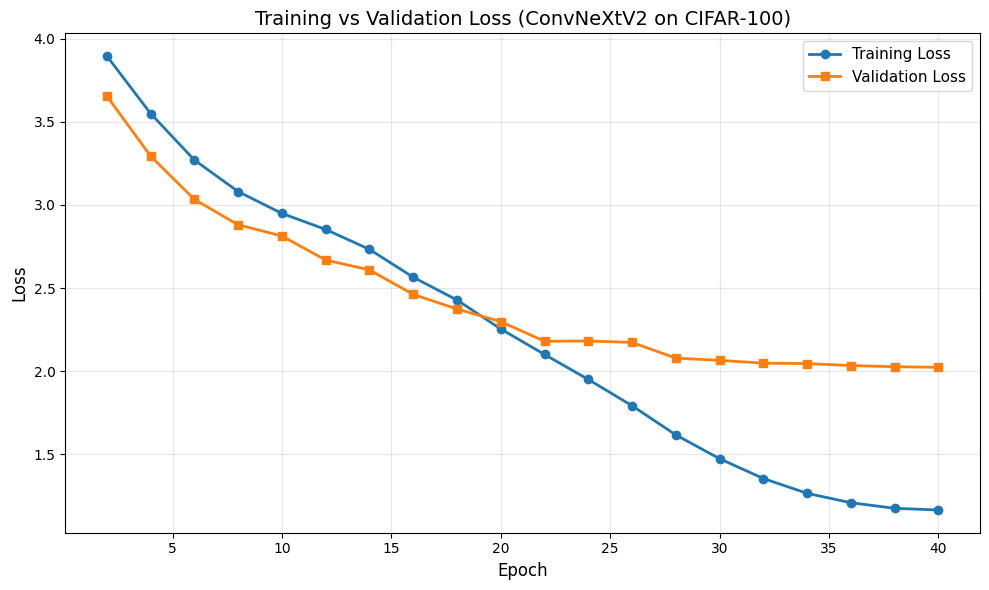


Final training loss: 1.1649
Final validation loss: 2.0234
Gap (val - train): 0.8585
✗ Significant overfitting detected


In [4]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(epochs_recorded, train_losses, label='Training Loss', linewidth=2, marker='o')
plt.plot(epochs_recorded, val_losses, label='Validation Loss', linewidth=2, marker='s')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training vs Validation Loss (ConvNeXtV2 on CIFAR-100)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('convnextv2_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Print final gap analysis
final_gap = val_losses[-1] - train_losses[-1]
print(f"\nFinal training loss: {train_losses[-1]:.4f}")
print(f"Final validation loss: {val_losses[-1]:.4f}")
print(f"Gap (val - train): {final_gap:.4f}")

if final_gap < 0.1:
    print("✓ Model shows good generalization (small gap)")
elif final_gap < 0.3:
    print("⚠ Mild overfitting detected")
else:
    print("✗ Significant overfitting detected")